# English Premier League Teams + Players (2014 - 2019)

## About Dataset
This dataset holds the relevant [understat.com](https://understat.com) data for all seasons from 2014- present for all the players and teams they play for. The data available is for English Premier League only. As those were the only data I needed for a separate project I am doing. Regardless, if anybody needs data for other leagues as well, raise an issue, I will try to add them as well. Once the season starts I will update the data after each game-week. I will be updating the data for each game-week once the new season starts.

### What is available in this dataset:
- Data for each player for last 3, 5, and 10 GW
- Data for an individual player for the whole season
- Data for an individual team going from last season up to 2014/15 season based on where they finished in the respective season
- Each team's complete data from 2014/15 to 2019/20 season

**Source:** [understat.com](https://understat.com)


## EPL Data Exploration

In [1]:
from glob import glob
import pandas as pd
import numpy as np
import jupyter_black
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

jupyter_black.load()

In [2]:
# Retrieve all .csv files in the "Data/Team_Data" directory and its subdirectories
team_files = glob("Data/Team_Data/*/*.csv")
team_files

['Data/Team_Data\\2014_season\\Arsenal_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Aston Villa_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Burnley_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Chelsea_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Crystal Palace_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Everton_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Hull_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Leicester_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Liverpool_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Manchester City_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Manchester United_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Newcastle United_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Queens Park Rangers_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Southampton_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Stoke_2014_season data.csv',
 'Data/Team_Data\

In [3]:
example_file = team_files[0]
example_file

'Data/Team_Data\\2014_season\\Arsenal_2014_season data.csv'

In [4]:
df = pd.read_csv(example_file)

In [5]:
df.head()

,GW,date,result,Home/Away,xG,scored,xGA,conceded,xpts,pts,npxG,npxGA,ppda,ppda_allowed,ppda_coef,oppda_coef,deep,deep_allowed,npxGD
0,1,2014-08-16 17:30:00,w,h,1.55411,2,0.158151,1,2.7946,3,1.55411,0.158151,"{'att': 88, 'def': 30}","{'att': 411, 'def': 29}",2.933333,14.172414,9,0,1.395959
1,2,2014-08-23 17:30:00,d,a,1.43355,2,1.334290,2,1.4293,1,1.43355,1.334290,"{'att': 257, 'def': 33}","{'att': 270, 'def': 17}",7.787879,15.882353,8,3,0.099260
2,3,2014-08-31 16:00:00,d,a,2.29649,1,0.809743,1,2.4128,1,2.29649,0.809743,"{'att': 150, 'def': 20}","{'att': 341, 'def': 31}",7.500000,11.000000,13,4,1.486747
3,4,2014-09-13 12:45:00,d,h,2.07804,2,2.308340,2,1.2271,1,2.07804,2.308340,"{'att': 262, 'def': 37}","{'att': 221, 'def': 44}",7.081081,5.022727,9,16,-0.230300
4,5,2014-09-20 15:00:00,w,a,1.36224,3,0.649013,0,2.0028,3,1.36224,0.649013,"{'att': 170, 'def': 22}","{'att': 531, 'def': 12}",7.727273,44.250000,7,0,0.713227


In [8]:
team_files[:10]

['Data/Team_Data\\2014_season\\Arsenal_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Aston Villa_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Burnley_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Chelsea_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Crystal Palace_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Everton_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Hull_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Leicester_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Liverpool_2014_season data.csv',
 'Data/Team_Data\\2014_season\\Manchester City_2014_season data.csv']

In [9]:
example_file.split("\\")[-1].split("_")

['Arsenal', '2014', 'season data.csv']

In [4]:
def process_file(team_file, verbose=False):
    """
    Parses the name of the file and extracts the team name and season.

    Returns a dataframe with the season data including team name and season as a column.
    """

    team_name, season, _ = team_file.split("\\")[-1].split("_")
    df = pd.read_csv(team_file)
    df = df.assign(team_name=team_name, season=season)

    if verbose:
        print(
            f"Running for team: {team_name} - Season {season} - Data is of shape {df.shape}\n"
        )
    return df


process_file(example_file, verbose=True)

Running for team: Arsenal - Season 2014 - Data is of shape (38, 21)



,GW,date,result,Home/Away,xG,scored,xGA,conceded,xpts,pts,...,npxGA,ppda,ppda_allowed,ppda_coef,oppda_coef,deep,deep_allowed,npxGD,team_name,season
0,1,2014-08-16 17:30:00,w,h,1.554110,2,0.158151,1,2.7946,3,...,0.158151,"{'att': 88, 'def': 30}","{'att': 411, 'def': 29}",2.933333,14.172414,9,0,1.395959,Arsenal,2014
1,2,2014-08-23 17:30:00,d,a,1.433550,2,1.334290,2,1.4293,1,...,1.334290,"{'att': 257, 'def': 33}","{'att': 270, 'def': 17}",7.787879,15.882353,8,3,0.099260,Arsenal,2014
2,3,2014-08-31 16:00:00,d,a,2.296490,1,0.809743,1,2.4128,1,...,0.809743,"{'att': 150, 'def': 20}","{'att': 341, 'def': 31}",7.500000,11.000000,13,4,1.486747,Arsenal,2014
3,4,2014-09-13 12:45:00,d,h,2.078040,2,2.308340,2,1.2271,1,...,2.308340,"{'att': 262, 'def': 37}","{'att': 221, 'def': 44}",7.081081,5.022727,9,16,-0.230300,Arsenal,2014
4,5,2014-09-20 15:00:00,w,a,1.362240,3,0.649013,0,2.0028,3,...,0.649013,"{'att': 170, 'def': 22}","{'att': 531, 'def': 12}",7.727273,44.250000,7,0,0.713227,Arsenal,2014
5,6,2014-09-27 17:30:00,d,h,1.264700,1,0.673535,1,1.8651,1,...,0.673535,"{'att': 153, 'def': 28}","{'att': 334, 'def': 20}",5.464286,16.700000,10,4,0.591165,Arsenal,2014
6,7,2014-10-05 14:05:00,l,a,0.330699,0,1.402630,2,0.3612,0,...,0.641457,"{'att': 237, 'def': 21}","{'att': 255, 'def': 31}",11.285714,8.225806,6,3,-0.310758,Arsenal,2014
7,8,2014-10-18 15:00:00,d,h,2.148450,2,0.552062,2,2.5284,1,...,0.552062,"{'att': 253, 'def': 40}","{'att': 352, 'def': 8}",6.325000,44.000000,17,0,1.596388,Arsenal,2014
8,9,2014-10-25 15:00:00,w,a,1.470810,2,0.441491,0,2.2738,3,...,0.441491,"{'att': 194, 'def': 41}","{'att': 236, 'def': 31}",4.731707,7.612903,10,6,1.029319,Arsenal,2014
9,10,2014-11-01 15:00:00,w,h,4.329800,3,0.684259,0,2.9540,3,...,0.684259,"{'att': 168, 'def': 20}","{'att': 312, 'def': 24}",8.400000,13.000000,19,2,3.645541,Arsenal,2014


In [5]:
dfs = []
for file in team_files:
    df = process_file(file)
    dfs.append(df)
team_df = pd.concat(dfs).reset_index(drop=True)

In [6]:
len(dfs)

120

In [7]:
team_df.head()

,GW,date,result,Home/Away,xG,scored,xGA,conceded,xpts,pts,...,npxGA,ppda,ppda_allowed,ppda_coef,oppda_coef,deep,deep_allowed,npxGD,team_name,season
0,1,2014-08-16 17:30:00,w,h,1.55411,2,0.158151,1,2.7946,3,...,0.158151,"{'att': 88, 'def': 30}","{'att': 411, 'def': 29}",2.933333,14.172414,9,0,1.395959,Arsenal,2014
1,2,2014-08-23 17:30:00,d,a,1.43355,2,1.334290,2,1.4293,1,...,1.334290,"{'att': 257, 'def': 33}","{'att': 270, 'def': 17}",7.787879,15.882353,8,3,0.099260,Arsenal,2014
2,3,2014-08-31 16:00:00,d,a,2.29649,1,0.809743,1,2.4128,1,...,0.809743,"{'att': 150, 'def': 20}","{'att': 341, 'def': 31}",7.500000,11.000000,13,4,1.486747,Arsenal,2014
3,4,2014-09-13 12:45:00,d,h,2.07804,2,2.308340,2,1.2271,1,...,2.308340,"{'att': 262, 'def': 37}","{'att': 221, 'def': 44}",7.081081,5.022727,9,16,-0.230300,Arsenal,2014
4,5,2014-09-20 15:00:00,w,a,1.36224,3,0.649013,0,2.0028,3,...,0.649013,"{'att': 170, 'def': 22}","{'att': 531, 'def': 12}",7.727273,44.250000,7,0,0.713227,Arsenal,2014


## Data Viz

<Axes: xlabel='xG', ylabel='xGA'>

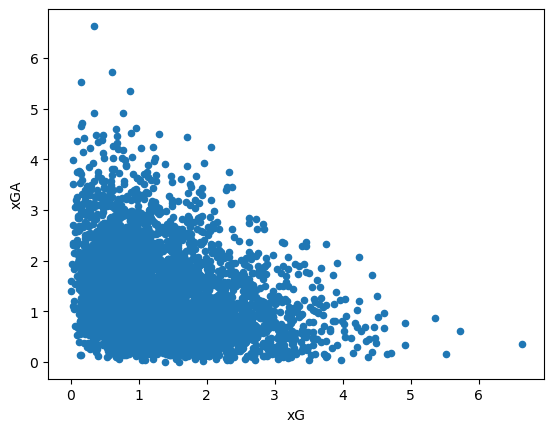

In [17]:
team_df.plot(x="xG", y="xGA", kind="scatter")

In [21]:
team_subset = team_df["team_name"].value_counts().head(9).index.tolist()
team_subset

['Arsenal',
 'Leicester',
 'Tottenham',
 'Southampton',
 'Manchester United',
 'West Ham',
 'Liverpool',
 'Manchester City',
 'Everton']

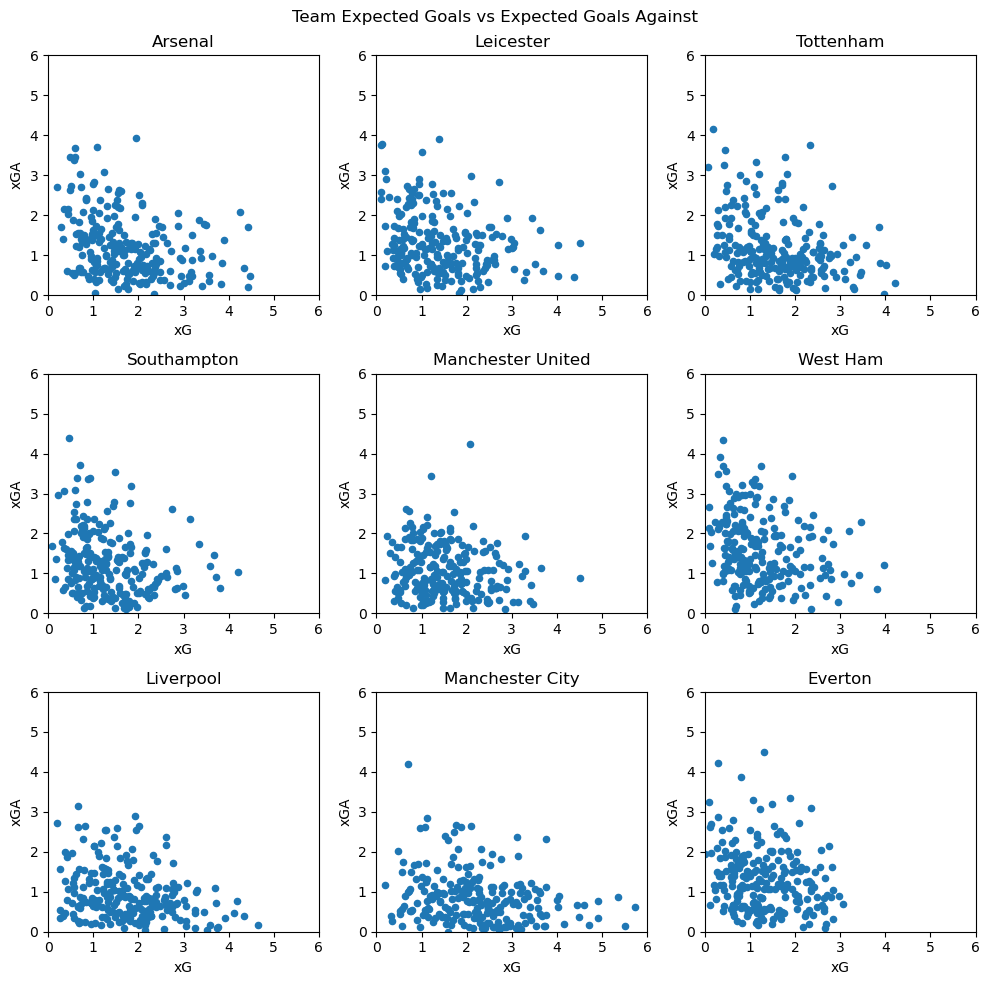

In [24]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
axs = axs.flatten()
fig.suptitle("Team Expected Goals vs Expected Goals Against")
for idx, ax in enumerate(axs):
    my_team = team_subset[idx]
    team_df.query("team_name == @my_team").plot(
        x="xG", y="xGA", kind="scatter", ax=axs[idx], title=my_team
    )
    axs[idx].set_xlim(0, 6)
    axs[idx].set_ylim(0, 6)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Expected Goals'}, ylabel='Frequency'>

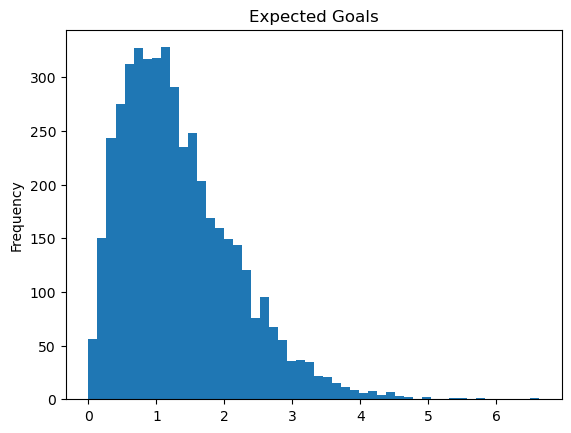

In [19]:
team_df["xG"].plot(kind="hist", bins=50, title="Expected Goals")

<Axes: title={'center': 'Avarage Expected Goals by Teams'}, ylabel='team_name'>

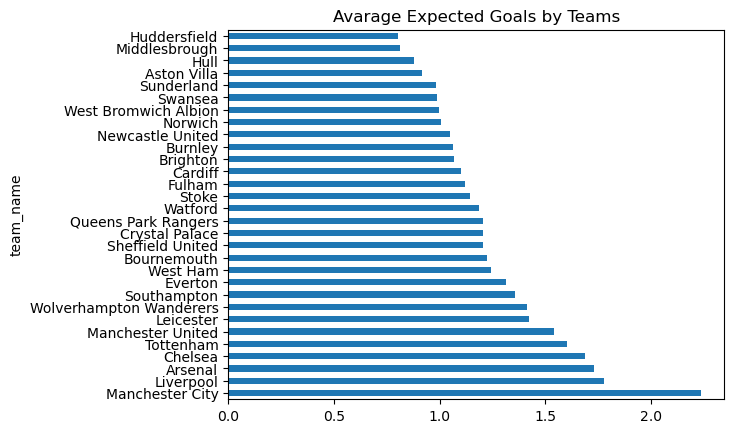

In [32]:
team_df.groupby("team_name")["xG"].mean().sort_values(ascending=False).plot(
    kind="barh", title="Avarage Expected Goals by Teams"
)

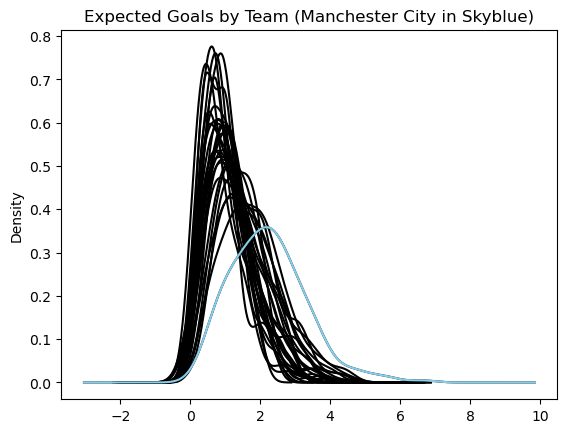

In [30]:
team_df.groupby("team_name")["xG"].plot(kind="kde", color="black")
team_df.query("team_name == 'Manchester City'")["xG"].plot(
    kind="kde",
    color="skyblue",
    title="Expected Goals by Team (Manchester City in Skyblue)",
    ylabel="Goals",
)
plt.show()

<Axes: xlabel='xG', ylabel='team_name'>

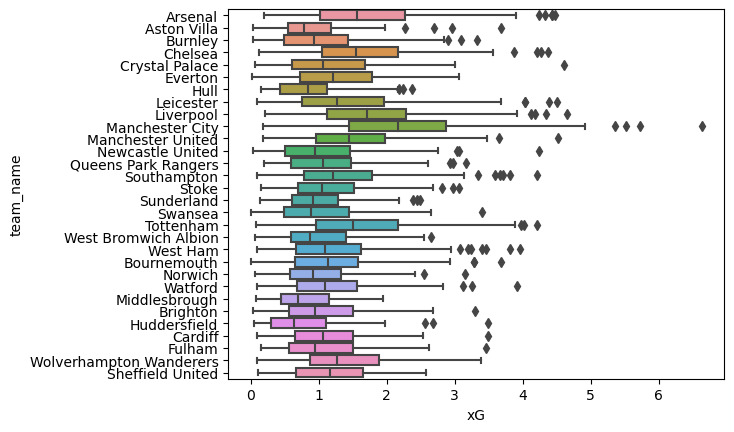

In [24]:
sns.boxplot(team_df, y="team_name", x="xG")

<Axes: xlabel='xG', ylabel='xGA'>

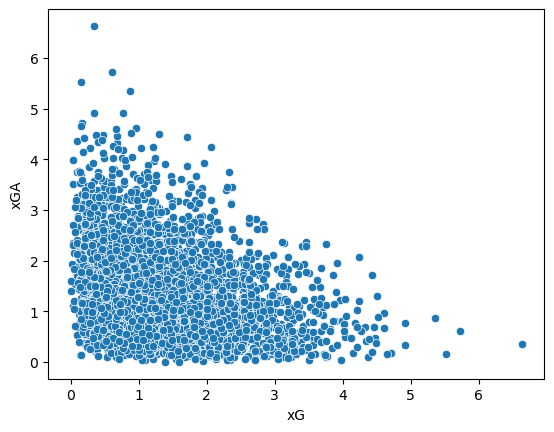

In [25]:
sns.scatterplot(team_df, y="xGA", x="xG")

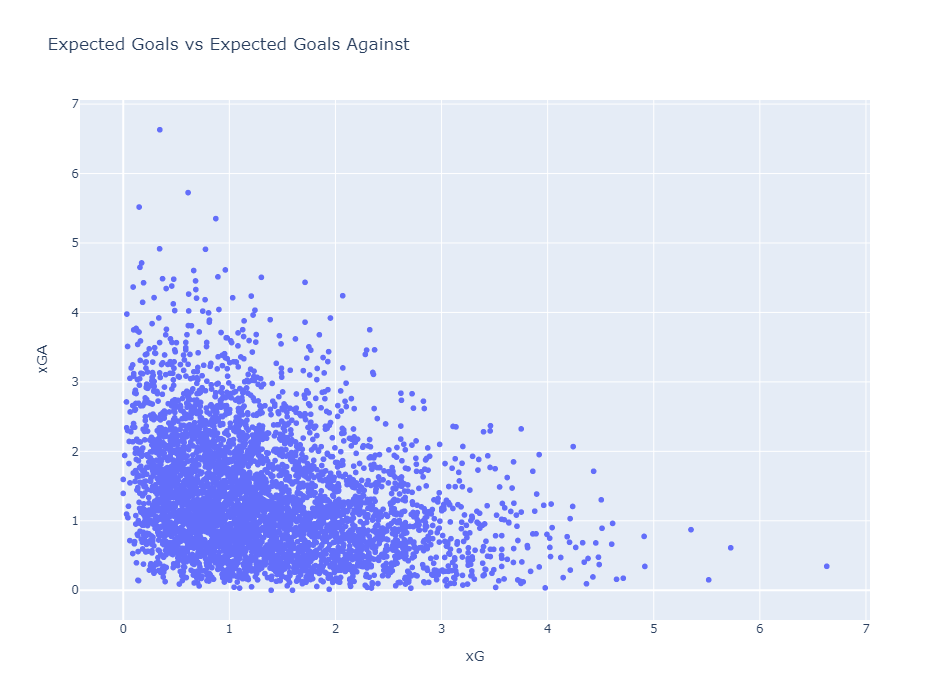

In [34]:
fig = px.scatter(
    team_df, x="xG", y="xGA", title="Expected Goals vs Expected Goals Against"
)

# Set the size of the plot
fig.update_layout(
    width=1000,  # Set the width in pixels
    height=700,  # Set the height in pixels
)

fig.show()

In [8]:
team_df[["scored", "conceded"]].value_counts()

scored  conceded
1       1           484
0       1           383
1       0           383
        2           348
2       1           348
0       0           330
        2           303
2       0           303
        2           244
3       1           178
1       3           178
3       0           163
0       3           163
3       2            91
2       3            91
4       0            77
0       4            77
4       1            66
1       4            66
3       3            34
5       0            30
0       5            30
4       2            27
2       4            27
1       5            20
5       1            20
4       3            12
3       4            12
6       1             9
1       6             9
2       5             6
5       2             6
        3             4
3       5             4
6       0             4
0       6             4
5       4             3
2       6             3
4       5             3
6       2             3
3       6             2

## Scorigami

In sports, a scorigami is a scoring combination that has never happened before in the history of a sport or league.

In [28]:
epl_scorigami = (
    team_df[["scored", "conceded"]].value_counts().unstack().sort_index(ascending=False)
).T

<Axes: xlabel='scored', ylabel='conceded'>

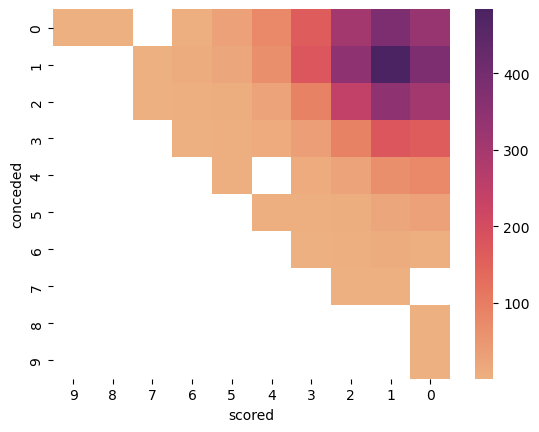

In [30]:
sns.heatmap(epl_scorigami, cmap="flare")

# Player Data

In [15]:
player_files = glob("Data/Player_Data/*/*.csv")
player_files

['Data/Player_Data\\gw_data\\last_10_gw_data.csv',
 'Data/Player_Data\\gw_data\\last_3_gw_data.csv',
 'Data/Player_Data\\gw_data\\last_5_gw_data.csv',
 'Data/Player_Data\\season_data\\2014_whole_season_data.csv',
 'Data/Player_Data\\season_data\\2015_whole_season_data.csv',
 'Data/Player_Data\\season_data\\2016_whole_season_data.csv',
 'Data/Player_Data\\season_data\\2017_whole_season_data.csv',
 'Data/Player_Data\\season_data\\2018_whole_season_data.csv',
 'Data/Player_Data\\season_data\\2019_whole_season_data.csv']

In [16]:
player_df = pd.read_csv(player_files[-1])

In [17]:
player_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 515 non-null    int64  
 1   player_name        515 non-null    object 
 2   games              515 non-null    int64  
 3   time               515 non-null    int64  
 4   goals_season       515 non-null    int64  
 5   xG_season          515 non-null    float64
 6   assists_season     515 non-null    int64  
 7   xA_season          515 non-null    float64
 8   shots_season       515 non-null    int64  
 9   key_passes_season  515 non-null    int64  
 10  yellow_cards       515 non-null    int64  
 11  red_cards          515 non-null    int64  
 12  position           515 non-null    object 
 13  team_title         515 non-null    object 
 14  npg_season         515 non-null    int64  
 15  npxG_season        515 non-null    float64
 16  xGChain            515 non

In [18]:
player_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,515.0,3527.143689,3048.962176,12.0,704.500000,1760.000000,6786.500000,8563.000000
games,515.0,20.609709,11.722351,1.0,10.000000,21.000000,31.000000,38.000000
time,515.0,1458.862136,1049.086480,1.0,562.000000,1331.000000,2364.000000,3420.000000
goals_season,515.0,1.943689,3.606999,0.0,0.000000,1.000000,2.000000,23.000000
xG_season,515.0,2.132619,3.555342,0.0,0.099912,0.763006,2.387409,21.015201
assists_season,515.0,1.368932,2.156297,0.0,0.000000,1.000000,2.000000,20.000000
xA_season,515.0,1.520651,2.054889,0.0,0.089775,0.815261,2.288873,20.620707
shots_season,515.0,18.240777,22.551633,0.0,2.000000,11.000000,24.000000,132.000000
key_passes_season,515.0,13.613592,16.628588,0.0,2.000000,7.000000,20.000000,133.000000
yellow_cards,515.0,2.483495,2.643769,0.0,0.000000,2.000000,4.000000,12.000000


## Data Cleaning

In [19]:
player_df.isnull().sum()

id                   0
player_name          0
games                0
time                 0
goals_season         0
xG_season            0
assists_season       0
xA_season            0
shots_season         0
key_passes_season    0
yellow_cards         0
red_cards            0
position             0
team_title           0
npg_season           0
npxG_season          0
xGChain              0
xGBuildup            0
dtype: int64

In [20]:
# Check for duplicates
duplicates = player_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [21]:
# Standardize text data
player_df["player_name"] = player_df["player_name"].str.title()  # Capitalize each word
player_df["position"] = player_df["position"].str.upper()  # Convert to uppercase
player_df["team_title"] = player_df["team_title"].str.title()  # Capitalize each word

In [22]:
# Convert categorical columns to 'category' data type to save memory and improve performance
player_df["position"] = player_df["position"].astype("category")
player_df["team_title"] = player_df["team_title"].astype("category")

In [23]:
# Validate goals_season
invalid_goals = player_df[player_df["goals_season"] < 0]
print(f"Number of invalid goals_season entries: {len(invalid_goals)}")

# Ensure 'time' is non-negative
invalid_time = player_df[player_df["time"] < 0]
print(f"Number of invalid time entries: {len(invalid_time)}")

Number of invalid goals_season entries: 0
Number of invalid time entries: 0


In [24]:
# Identify outliers using the IQR method

for col in [
    "goals_season",
    "xG_season",
    "assists_season",
    "xA_season",
    "shots_season",
    "key_passes_season",
    "yellow_cards",
    "red_cards",
    "npg_season",
    "npxG_season",
    "xGChain",
    "xGBuildup",
]:
    Q1 = player_df[col].quantile(0.25)
    Q3 = player_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = player_df[
        (player_df[col] < lower_bound) | (player_df[col] > upper_bound)
    ]
    print(f"Number of outliers in {col}: {len(outliers)}")

Number of outliers in goals_season: 50
Number of outliers in xG_season: 57
Number of outliers in assists_season: 27
Number of outliers in xA_season: 27
Number of outliers in shots_season: 37
Number of outliers in key_passes_season: 26
Number of outliers in yellow_cards: 2
Number of outliers in red_cards: 41
Number of outliers in npg_season: 45
Number of outliers in npxG_season: 52
Number of outliers in xGChain: 20
Number of outliers in xGBuildup: 18


**Goals in the 2019 Season**

In [25]:
player_df.goals_season.value_counts()

goals_season
0     253
1      90
2      58
3      30
4      20
5      14
6      10
8       7
10      5
9       4
7       4
11      3
14      3
17      3
13      2
22      2
18      2
15      1
16      1
19      1
20      1
23      1
Name: count, dtype: int64

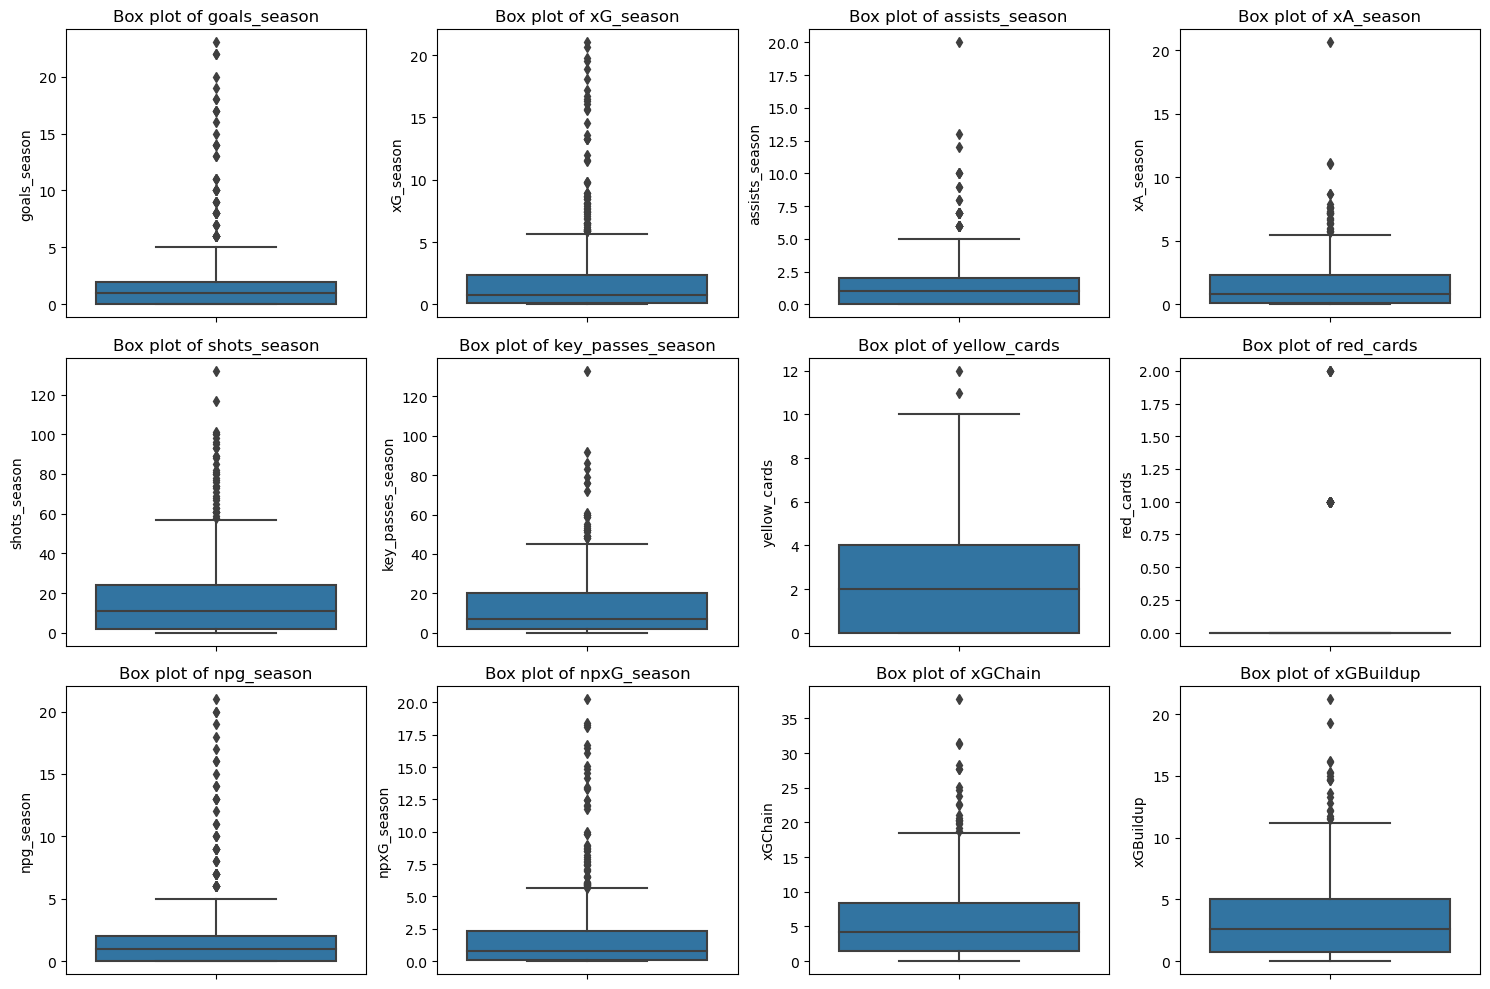

In [26]:
plt.figure(figsize=(15, 10))
numerical_columns = [
    "goals_season",
    "xG_season",
    "assists_season",
    "xA_season",
    "shots_season",
    "key_passes_season",
    "yellow_cards",
    "red_cards",
    "npg_season",
    "npxG_season",
    "xGChain",
    "xGBuildup",
]

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(y=player_df[col])
    plt.title(f"Box plot of {col}")
plt.tight_layout()
plt.show()

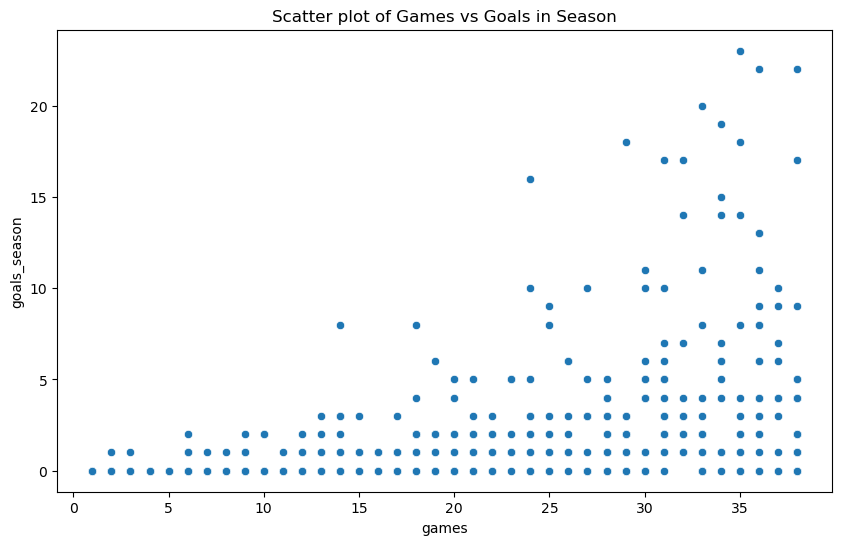

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=player_df, x="games", y="goals_season")
plt.title("Scatter plot of Games vs Goals in Season")
plt.show()

In [28]:
# pd.set_option("display.max_columns", 50)

In [29]:
player_df

,id,player_name,games,time,goals_season,xG_season,assists_season,xA_season,shots_season,key_passes_season,yellow_cards,red_cards,position,team_title,npg_season,npxG_season,xGChain,xGBuildup
0,755,Jamie Vardy,35,3034,23,18.903537,5,6.368298,89,32,3,0,F S,Leicester,19,15.097693,21.026607,1.724341
1,318,Pierre-Emerick Aubameyang,36,3143,22,16.352623,3,4.492487,93,26,3,1,F M S,Arsenal,20,14.830359,19.964282,5.339657
2,986,Danny Ings,38,2836,22,15.659717,2,2.849085,93,35,3,0,F M S,Southampton,21,14.137379,18.488031,5.015938
3,618,Raheem Sterling,33,2678,20,19.799906,1,7.208586,100,48,5,0,F M S,Manchester City,20,18.277569,31.442010,10.185997
4,1250,Mohamed Salah,34,2904,19,20.663319,10,8.726043,132,60,1,0,F S,Liverpool,16,18.379812,31.374198,8.425027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,8493,Jake Vokins,1,90,0,0.013284,0,0.096596,1,1,0,0,D,Southampton,0,0.013284,0.501861,0.488577
511,8496,Tommy Doyle,1,13,0,0.077601,0,0.000000,1,0,0,0,S,Manchester City,0,0.077601,0.077601,0.000000
512,8518,Jordan Thomas,1,1,0,0.000000,0,0.000000,0,0,0,0,S,Norwich,0,0.000000,0.000000,0.000000
513,8562,Luke Thomas,3,270,0,0.000000,1,0.629982,0,9,0,0,M,Leicester,0,0.000000,1.378853,1.267736


In [30]:
player_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 515 non-null    int64   
 1   player_name        515 non-null    object  
 2   games              515 non-null    int64   
 3   time               515 non-null    int64   
 4   goals_season       515 non-null    int64   
 5   xG_season          515 non-null    float64 
 6   assists_season     515 non-null    int64   
 7   xA_season          515 non-null    float64 
 8   shots_season       515 non-null    int64   
 9   key_passes_season  515 non-null    int64   
 10  yellow_cards       515 non-null    int64   
 11  red_cards          515 non-null    int64   
 12  position           515 non-null    category
 13  team_title         515 non-null    category
 14  npg_season         515 non-null    int64   
 15  npxG_season        515 non-null    float64 
 16  xGChain 

In [31]:
team_df

,GW,date,result,Home/Away,xG,scored,xGA,conceded,xpts,pts,...,npxGA,ppda,ppda_allowed,ppda_coef,oppda_coef,deep,deep_allowed,npxGD,team_name,season
0,1,2014-08-16 17:30:00,w,h,1.554110,2,0.158151,1,2.7946,3,...,0.158151,"{'att': 88, 'def': 30}","{'att': 411, 'def': 29}",2.933333,14.172414,9,0,1.395959,Arsenal,2014
1,2,2014-08-23 17:30:00,d,a,1.433550,2,1.334290,2,1.4293,1,...,1.334290,"{'att': 257, 'def': 33}","{'att': 270, 'def': 17}",7.787879,15.882353,8,3,0.099260,Arsenal,2014
2,3,2014-08-31 16:00:00,d,a,2.296490,1,0.809743,1,2.4128,1,...,0.809743,"{'att': 150, 'def': 20}","{'att': 341, 'def': 31}",7.500000,11.000000,13,4,1.486747,Arsenal,2014
3,4,2014-09-13 12:45:00,d,h,2.078040,2,2.308340,2,1.2271,1,...,2.308340,"{'att': 262, 'def': 37}","{'att': 221, 'def': 44}",7.081081,5.022727,9,16,-0.230300,Arsenal,2014
4,5,2014-09-20 15:00:00,w,a,1.362240,3,0.649013,0,2.0028,3,...,0.649013,"{'att': 170, 'def': 22}","{'att': 531, 'def': 12}",7.727273,44.250000,7,0,0.713227,Arsenal,2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,34,2020-07-08 17:00:00,l,a,0.326909,0,0.470483,1,1.0775,0,...,0.470483,"{'att': 154, 'def': 13}","{'att': 340, 'def': 18}",11.846154,18.888889,2,7,-0.143574,Wolverhampton Wanderers,2019
4556,35,2020-07-12 11:00:00,w,h,2.867240,3,0.286561,0,2.8945,3,...,0.286561,"{'att': 287, 'def': 20}","{'att': 354, 'def': 19}",14.350000,18.631579,4,3,1.819509,Wolverhampton Wanderers,2019
4557,36,2020-07-15 17:00:00,d,a,1.285700,1,1.534350,1,1.0986,1,...,0.773179,"{'att': 180, 'def': 8}","{'att': 201, 'def': 26}",22.500000,7.730769,3,6,0.512521,Wolverhampton Wanderers,2019
4558,37,2020-07-20 19:15:00,w,h,1.486960,2,0.440119,0,2.3593,3,...,0.440119,"{'att': 240, 'def': 17}","{'att': 257, 'def': 22}",14.117647,11.681818,4,1,1.046841,Wolverhampton Wanderers,2019


In [32]:
team_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4560 entries, 0 to 4559
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GW            4560 non-null   int64  
 1   date          4560 non-null   object 
 2   result        4560 non-null   object 
 3   Home/Away     4560 non-null   object 
 4   xG            4560 non-null   float64
 5   scored        4560 non-null   int64  
 6   xGA           4560 non-null   float64
 7   conceded      4560 non-null   int64  
 8   xpts          4560 non-null   float64
 9   pts           4560 non-null   int64  
 10  npxG          4560 non-null   float64
 11  npxGA         4560 non-null   float64
 12  ppda          4560 non-null   object 
 13  ppda_allowed  4560 non-null   object 
 14  ppda_coef     4560 non-null   float64
 15  oppda_coef    4560 non-null   float64
 16  deep          4560 non-null   int64  
 17  deep_allowed  4560 non-null   int64  
 18  npxGD         4560 non-null 

### Feature Engineering

In [33]:
# Create rolling averages for goals and xG for players
player_df["goals_rolling_avg"] = player_df.groupby("player_name")[
    "goals_season"
].transform(lambda x: x.rolling(window=3).mean())

player_df["xG_rolling_avg"] = player_df.groupby("player_name")["xG_season"].transform(
    lambda x: x.rolling(window=3).mean()
)

# Create rolling averages for team xG and xGA
team_df["team_xG_rolling_avg"] = team_df.groupby("team_name")["xG"].transform(
    lambda x: x.rolling(window=3).mean()
)

team_df["team_xGA_rolling_avg"] = team_df.groupby("team_name")["xGA"].transform(
    lambda x: x.rolling(window=3).mean()
)

In [34]:
# Calculate per-game metrics for players
player_df["goals_per_game"] = player_df["goals_season"] / player_df["games"]
player_df["xG_per_game"] = player_df["xG_season"] / player_df["games"]

# Calculate ratios for players
player_df["xG_to_goals_ratio"] = player_df["xG_season"] / player_df["goals_season"]

# Calculate per-game metrics for teams
team_df["team_goals_per_game"] = team_df["scored"] / team_df["GW"]
team_df["team_xG_per_game"] = team_df["xG"] / team_df["GW"]

In [35]:
# Calculate the rolling average for the last 3 game weeks
team_df["team_xG_rolling_avg"] = team_df.groupby("team_name")["xG"].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# Interaction features between player and team metrics
player_df["player_team_xG_interaction"] = (
    player_df["xG_season"] * team_df["team_xG_rolling_avg"]
)

In [36]:
player_df

,id,player_name,games,time,goals_season,xG_season,assists_season,xA_season,shots_season,key_passes_season,...,npg_season,npxG_season,xGChain,xGBuildup,goals_rolling_avg,xG_rolling_avg,goals_per_game,xG_per_game,xG_to_goals_ratio,player_team_xG_interaction
0,755,Jamie Vardy,35,3034,23,18.903537,5,6.368298,89,32,...,19,15.097693,21.026607,1.724341,NaN,NaN,0.657143,0.540101,0.821893,29.378176
1,318,Pierre-Emerick Aubameyang,36,3143,22,16.352623,3,4.492487,93,26,...,20,14.830359,19.964282,5.339657,NaN,NaN,0.611111,0.454240,0.743301,24.428039
2,986,Danny Ings,38,2836,22,15.659717,2,2.849085,93,35,...,21,14.137379,18.488031,5.015938,NaN,NaN,0.578947,0.412098,0.711805,27.582765
3,618,Raheem Sterling,33,2678,20,19.799906,1,7.208586,100,48,...,20,18.277569,31.442010,10.185997,NaN,NaN,0.606061,0.599997,0.989995,38.333147
4,1250,Mohamed Salah,34,2904,19,20.663319,10,8.726043,132,60,...,16,18.379812,31.374198,8.425027,NaN,NaN,0.558824,0.607745,1.087543,39.513569
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,8493,Jake Vokins,1,90,0,0.013284,0,0.096596,1,1,...,0,0.013284,0.501861,0.488577,NaN,NaN,0.000000,0.013284,inf,0.025481
511,8496,Tommy Doyle,1,13,0,0.077601,0,0.000000,1,0,...,0,0.077601,0.077601,0.000000,NaN,NaN,0.000000,0.077601,inf,0.135246
512,8518,Jordan Thomas,1,1,0,0.000000,0,0.000000,0,0,...,0,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000
513,8562,Luke Thomas,3,270,0,0.000000,1,0.629982,0,9,...,0,0.000000,1.378853,1.267736,NaN,NaN,0.000000,0.000000,NaN,0.000000


In [37]:
team_df

,GW,date,result,Home/Away,xG,scored,xGA,conceded,xpts,pts,...,oppda_coef,deep,deep_allowed,npxGD,team_name,season,team_xG_rolling_avg,team_xGA_rolling_avg,team_goals_per_game,team_xG_per_game
0,1,2014-08-16 17:30:00,w,h,1.554110,2,0.158151,1,2.7946,3,...,14.172414,9,0,1.395959,Arsenal,2014,1.554110,NaN,2.000000,1.554110
1,2,2014-08-23 17:30:00,d,a,1.433550,2,1.334290,2,1.4293,1,...,15.882353,8,3,0.099260,Arsenal,2014,1.493830,NaN,1.000000,0.716775
2,3,2014-08-31 16:00:00,d,a,2.296490,1,0.809743,1,2.4128,1,...,11.000000,13,4,1.486747,Arsenal,2014,1.761383,0.767395,0.333333,0.765497
3,4,2014-09-13 12:45:00,d,h,2.078040,2,2.308340,2,1.2271,1,...,5.022727,9,16,-0.230300,Arsenal,2014,1.936027,1.484124,0.500000,0.519510
4,5,2014-09-20 15:00:00,w,a,1.362240,3,0.649013,0,2.0028,3,...,44.250000,7,0,0.713227,Arsenal,2014,1.912257,1.255699,0.600000,0.272448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4555,34,2020-07-08 17:00:00,l,a,0.326909,0,0.470483,1,1.0775,0,...,18.888889,2,7,-0.143574,Wolverhampton Wanderers,2019,0.671875,0.718877,0.000000,0.009615
4556,35,2020-07-12 11:00:00,w,h,2.867240,3,0.286561,0,2.8945,3,...,18.631579,4,3,1.819509,Wolverhampton Wanderers,2019,1.393105,0.679925,0.085714,0.081921
4557,36,2020-07-15 17:00:00,d,a,1.285700,1,1.534350,1,1.0986,1,...,7.730769,3,6,0.512521,Wolverhampton Wanderers,2019,1.493283,0.763798,0.027778,0.035714
4558,37,2020-07-20 19:15:00,w,h,1.486960,2,0.440119,0,2.3593,3,...,11.681818,4,1,1.046841,Wolverhampton Wanderers,2019,1.879967,0.753677,0.054054,0.040188


In [38]:
# Merge the datasets on team name
merged_df = pd.merge(player_df, team_df, left_on="team_title", right_on="team_name")

In [39]:
merged_df = merged_df.drop(
    ["player_name", "id", "date"], axis=1
)  # Drop non-numeric, non-relevant columns

In [40]:
merged_df

,games,time,goals_season,xG_season,assists_season,xA_season,shots_season,key_passes_season,yellow_cards,red_cards,...,oppda_coef,deep,deep_allowed,npxGD,team_name,season,team_xG_rolling_avg,team_xGA_rolling_avg,team_goals_per_game,team_xG_per_game
0,35,3034,23,18.903537,5,6.368298,89,32,3,0,...,11.687500,1,15,0.665027,Leicester,2014,1.278300,NaN,2.000000,1.278300
1,35,3034,23,18.903537,5,6.368298,89,32,3,0,...,7.052632,1,12,-1.478496,Leicester,2014,0.914597,NaN,0.000000,0.275447
2,35,3034,23,18.903537,5,6.368298,89,32,3,0,...,7.500000,4,13,-1.486747,Leicester,2014,0.879646,1.646384,0.333333,0.269914
3,35,3034,23,18.903537,5,6.368298,89,32,3,0,...,6.782609,6,8,-1.049507,Leicester,2014,0.652983,1.991233,0.250000,0.149578
4,35,3034,23,18.903537,5,6.368298,89,32,3,0,...,6.692308,6,7,-0.692050,Leicester,2014,1.316752,1.885407,1.000000,0.508440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93627,2,5,0,0.100603,0,0.000000,3,0,0,0,...,17.111111,5,8,-0.287850,Leicester,2019,1.671017,0.991229,0.029412,0.029482
93628,2,5,0,0.100603,0,0.000000,3,0,0,0,...,18.470588,14,3,-0.121110,Leicester,2019,1.623350,1.446959,0.028571,0.047453
93629,2,5,0,0.100603,0,0.000000,3,0,0,0,...,10.173913,6,1,2.397306,Leicester,2019,1.906913,1.497851,0.055556,0.084931
93630,2,5,0,0.100603,0,0.000000,3,0,0,0,...,21.166667,6,2,0.433928,Leicester,2019,1.973070,1.323415,0.000000,0.032455


In [41]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93632 entries, 0 to 93631
Data columns (total 46 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   games                       93632 non-null  int64   
 1   time                        93632 non-null  int64   
 2   goals_season                93632 non-null  int64   
 3   xG_season                   93632 non-null  float64 
 4   assists_season              93632 non-null  int64   
 5   xA_season                   93632 non-null  float64 
 6   shots_season                93632 non-null  int64   
 7   key_passes_season           93632 non-null  int64   
 8   yellow_cards                93632 non-null  int64   
 9   red_cards                   93632 non-null  int64   
 10  position                    93632 non-null  category
 11  team_title                  93632 non-null  object  
 12  npg_season                  93632 non-null  int64   
 13  npxG_season     

# Model Building

In [58]:
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [43]:
# Define features
numeric_features = [
    "games",
    "time",
    "xG_season",
    "assists_season",
    "xA_season",
    "shots_season",
    "key_passes_season",
    "npxG_season",
    "xGChain",
    "xGBuildup",
    "goals_per_game",
    "xG_per_game",
    "player_team_xG_interaction",
    "team_xG_rolling_avg",
    "team_xGA_rolling_avg",
    "team_goals_per_game",
    "team_xG_per_game",
]

categorical_features = ["position", "team_title", "Home/Away", "result"]

In [44]:
# Create numeric transformer with imputation
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]
)

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Define pipeline with a placeholder regressor
model = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(random_state=42),
        ),  # Default regressor, will be replaced in grid search
    ]
)

In [45]:
# Prepare the features and target
X = merged_df[numeric_features + categorical_features]
y = merged_df["goals_season"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
# Define hyperparameters for grid search
param_grid = [
    {
        "regressor": [RandomForestRegressor(random_state=42)],
        "regressor__n_estimators": [100, 200],
        "regressor__max_depth": [10, 20, None],
        "regressor__min_samples_split": [2, 5],
        "regressor__min_samples_leaf": [1, 2],
    },
    {"regressor": [Lasso(random_state=42)], "regressor__alpha": [0.1, 1.0, 10.0]},
    {
        "regressor": [XGBRegressor(random_state=42)],
        "regressor__n_estimators": [100, 200],
        "regressor__max_depth": [3, 6, 10],
        "regressor__learning_rate": [0.01, 0.1, 0.3],
    },
]

In [48]:
# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    model, param_grid, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1
)
grid_search.fit(X, y)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['games',
                                                                          'time',
                                                                          'xG_season',
                                                                          'assists_season',
                                                                          'xA_season',
                                                                          'shots_season',
                                                                          'key_passes_season',
                                                                          'npxG_season',
                                                                          'xGChain',
                                                                          'xGBuildup',
                                                                          'goa...
                                                     max_delta_step=None,
                                                     max_depth=None,
                                                     max_leaves=None,
                                                     min_child_weight=None,
                                                     missing=nan,
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=None,
                                                     n_jobs=None,
                                                     num_parallel_tree=None,
                                                     random_state=42, ...)],
                          'regressor__learning_rate': [0.01, 0.1, 0.3],
                          'regressor__max_depth': [3, 6, 10],
                          'regressor__n_estimators': [100, 200]}],
             scoring='neg_mean_squared_error')

In [56]:
print("Best parameters found:")
grid_search.best_params_

Best parameters found:


{'regressor': RandomForestRegressor(max_depth=10, random_state=42),
 'regressor__max_depth': 10,
 'regressor__min_samples_leaf': 1,
 'regressor__min_samples_split': 2,
 'regressor__n_estimators': 100}

**Interpretation**:
- The best model found by the grid search is a `RandomForestRegressor` with the following hyperparameters:
  - `max_depth=10`: The maximum depth of each tree in the forest is limited to 10 levels. This helps in controlling overfitting by not allowing trees to grow too deep.
  - `min_samples_leaf=1`: Each leaf node must have at least one sample. This is the smallest possible value, allowing trees to split until the last possible division.
  - `min_samples_split=2`: A node must have at least 2 samples to consider splitting. This is the smallest possible value.
  - `n_estimators=100`: The forest consists of 100 trees. This is a common default value providing a good balance between performance and computational efficiency.

In [57]:
print("Best cross-validation score:")
grid_search.best_score_

Best cross-validation score:


0.0

- The cross-validation score is `0.0`, and both the mean and standard deviation of cross-validation scores are also `0.0`.

In [59]:
# Calculate the mean and standard deviation of the cross-validation scores for the best model
mean_cv_score = grid_search.cv_results_["mean_test_score"][grid_search.best_index_]
std_cv_score = grid_search.cv_results_["std_test_score"][grid_search.best_index_]

print(f"Mean cross-validation score: {mean_cv_score}")
print(f"Standard deviation of cross-validation scores: {std_cv_score}")

Mean cross-validation score: 0.0
Standard deviation of cross-validation scores: 0.0


**Interpretation**:
- Since the scoring metric used in `GridSearchCV` was `neg_mean_squared_error`, a score of `0.0` indicates that the model achieved perfect predictions (i.e., no error) across all cross-validation folds. 
- A standard deviation of `0.0` suggests that the model's performance was consistent across all folds, with no variation in the scores.

In [50]:
# Evaluate the model on the test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

In [51]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [52]:
print(f"Test set mean squared error: {mse}")
print(f"Test set R^2 score: {r2}")

Test set mean squared error: 0.0
Test set R^2 score: 1.0


**Interpretation**:
- **Test set mean squared error (MSE)**: `0.0`
  - The mean squared error of `0.0` on the test set indicates that the model made perfect predictions with no errors.
- **Test set R² score**: `1.0`
  - The R² score of `1.0` indicates perfect fit, meaning the model explains 100% of the variance in the target variable.

### Overall Interpretation

The results suggest that the model is performing exceptionally well, with perfect predictions on both the cross-validation and test sets. This could be due to several reasons:

1. **Data Quality**:
   - The dataset might have perfectly predictable patterns, allowing the model to make exact predictions.

2. **Model Overfitting**:
   - The model might have overfitted the training data, learning noise or patterns that are not generalizable. However, given the perfect score on the test set as well, this might not be the case here.

3. **Possible Data Leakage**:
   - There might be a data leakage issue, where information from the test set has inadvertently been used in training. This can lead to unrealistically high performance metrics.

4. **Simplistic Data**:
   - The target variable (`goals_season`) might be directly or easily predictable from the features provided.

### Next Steps

Given these perfect scores, it would be prudent to:
- Double-check for data leakage or any preprocessing steps that might have inadvertently used future information.
- Verify the realism of the dataset and the relationship between features and the target variable.
- Consider introducing more realistic noise or more complex cross-validation techniques to ensure the model's robustness and generalizability.

In [60]:
# Get feature importances or coefficients
feature_names = (
    numeric_features
    + best_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

In [70]:
# Extract feature importances or coefficients
regressor = best_model.named_steps["regressor"]

if isinstance(regressor, RandomForestRegressor):
    feature_importance = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": regressor.feature_importances_,
        }
    )
    print("Top 10 most important features (Random Forest):")

elif isinstance(regressor, XGBRegressor):
    feature_importance = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": regressor.feature_importances_,
        }
    )
    print("Top 10 most important features (XGBoost):")

else:
    feature_importance = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": abs(regressor.coef_),
        }
    )
    print("Top 10 most important features (Lasso):")

# Sort and print the top 10 most important features
feature_importance.sort_values("importance", ascending=False).head(10)

Top 10 most important features (Random Forest):


,feature,importance
2,xG_season,0.658363
10,goals_per_game,0.256030
12,player_team_xG_interaction,0.031529
5,shots_season,0.026765
0,games,0.012520
1,time,0.007216
9,xGBuildup,0.001483
6,key_passes_season,0.001409
8,xGChain,0.001157
4,xA_season,0.001131


## Interpretation of feature importance:

1. **xG_season (0.658363)**
   - **Interpretation**: Expected goals (xG) for the season is the most important feature. This suggests that the model heavily relies on this feature to predict the number of goals scored in a season. xG is a metric that estimates the probability of a shot resulting in a goal based on various factors such as distance, angle, and type of assist. A higher xG indicates more high-quality scoring opportunities, which naturally correlates with a higher number of goals.

2. **goals_per_game (0.256030)**
   - **Interpretation**: Goals per game is another crucial feature. This feature directly reflects the player’s scoring efficiency on a game-by-game basis, making it a strong predictor for the total goals in a season.

3. **player_team_xG_interaction (0.031529)**
   - **Interpretation**: This feature represents the interaction effect between the player and the team's expected goals. It highlights how well the player's performance aligns with the overall team's scoring opportunities. A positive interaction can indicate that the player benefits from the team's style and quality of play.

4. **shots_season (0.026765)**
   - **Interpretation**: The number of shots taken during the season is also significant. More shots generally increase the chances of scoring, which explains its importance in predicting goals.

5. **games (0.012520)**
   - **Interpretation**: The number of games played is important because more playing time provides more opportunities to score. Players who participate in more games are likely to have more chances to accumulate goals.

6. **time (0.007216)**
   - **Interpretation**: The total time played during the season reflects a player’s involvement in games. More playing time means more opportunities to influence the game and score goals.

7. **xGBuildup (0.001483)**
   - **Interpretation**: Expected goals buildup measures the contribution to the expected goals in possession without key passes and shots. It reflects a player's involvement in the build-up phase, indicating their role in creating scoring opportunities indirectly.

8. **key_passes_season (0.001409)**
   - **Interpretation**: Key passes are passes that lead directly to a shot on goal. Although less important than other features, it still contributes to predicting goals as it reflects the player's ability to create scoring opportunities for themselves and others.

9. **xGChain (0.001157)**
   - **Interpretation**: Expected goals chain measures the total xG of every possession the player is involved in. It indicates the player's overall involvement in creating goal-scoring opportunities, though its lower importance suggests that direct goal contributions are more predictive.

10. **xA_season (0.001131)**
    - **Interpretation**: Expected assists (xA) estimates the likelihood that a given pass will become a goal assist. While primarily a measure of playmaking, it still has some relevance to goal scoring as it indicates the player’s involvement in goal creation.

### Summary
The most important features are directly related to the quality and quantity of scoring opportunities (xG_season, goals_per_game) and the player's involvement in creating these opportunities (player_team_xG_interaction, shots_season). Features reflecting playing time (games, time) are also significant, as they provide context to a player's opportunity to score throughout the season. Indirect measures of goal creation (xGBuildup, key_passes_season, xGChain, xA_season) play a smaller but still notable role in the prediction model. This indicates that while direct measures of scoring opportunities are paramount, the player's overall involvement in the game and their team's play also contributes to their goal-scoring tally.

## Save the Pipeline

In [71]:
import joblib

In [72]:
# Save the pipeline to a file
joblib.dump(grid_search.best_estimator_, "trained_pipeline.joblib")

['trained_pipeline.joblib']

In [73]:
# Load the pipeline from the file
EPL_pipeline = joblib.load("trained_pipeline.joblib")

In [74]:
EPL_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['games', 'time', 'xG_season',
                                                   'assists_season',
                                                   'xA_season', 'shots_season',
                                                   'key_passes_season',
                                                   'npxG_season', 'xGChain',
                                                   'xGBuildup',
                                                   'goals_per_game',
                                                   'xG_per_game',
                                                   'player_team_xG_interaction',
                                                   'team_xG_rolling_avg',
                                                   'team_xGA_rolling_avg',
                                                   'team_goals_per_game',
                                                   'team_xG_per_game']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['position', 'team_title',
                                                   'Home/Away', 'result'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=10, random_state=42))])